# Notebook 00: Load & Assign SRK S-Allele Genotype Data

This notebook loads SRK (S-locus Receptor Kinase) **S-allele** data for **slickspot peppergrass**
(*Lepidium papilliferum*), assigns tetraploid genotypes from allele copy-count matrices,
and exports population data for downstream analysis.

## Key Differences from Protein-Based Approach

| Feature | Old (protein-based) | New (S-allele-based) |
|---|---|---|
| Genotype matrix | Binary presence/absence (`SRK_individual_genotypes.tsv`) | Copy-count matrix (`SRK_individual_allele_genotypes.tsv`) |
| Allele resolution | Required `SRK_individual_protein_table.tsv` read counts for AABC | Count matrix directly encodes copy counts per allele bin |
| Allele identifiers | `SRK_protein_001` … `SRK_protein_094` | `Allele_002` … `Allele_050` |
| Genotype patterns | AAAA, AABB, AABC, ABCD | AAAA, AABB, **AAAB**, AABC |

## Input Files

- `SRK_individual_allele_genotypes.tsv` — count matrix (individuals × allele bins; values = distinct protein count per bin)
- `SRK_individual_zygosity.tsv` — zygosity table with `Genotype` pattern and `Allele_composition`
- `sampling_metadata.csv` — population/library metadata
- `SRK_individual_allele_table.tsv` — long-format allele table (optional, used for cross-validation)


In [1]:
import os
import re
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---------------------------------------------------------------------------
# Configuration — set SALLELES_DIR to the folder containing the S-allele files
# Default: data/salleles/  (copy pipeline outputs there, or adjust path below)
# ---------------------------------------------------------------------------
DATA_DIR = os.path.join("..", "data")
SALLELES_DIR = os.path.join(DATA_DIR, "salleles")

os.makedirs(SALLELES_DIR, exist_ok=True)
print(f"S-allele data directory: {os.path.abspath(SALLELES_DIR)}")
print("Place the following pipeline output files in that directory:")
print("  SRK_individual_allele_genotypes.tsv")
print("  SRK_individual_zygosity.tsv")
print("  SRK_individual_allele_table.tsv  (optional)")
print("  sampling_metadata.csv")
print("Imports loaded.")

S-allele data directory: /Users/jimbeck/Repos/polyploid-model/data/salleles
Place the following pipeline output files in that directory:
  SRK_individual_allele_genotypes.tsv
  SRK_individual_zygosity.tsv
  SRK_individual_allele_table.tsv  (optional)
  sampling_metadata.csv
Imports loaded.


## 1. Load Data Files

Load the three required data files (`encoding='utf-8-sig'` handles BOM from Excel-touched TSVs).

In [2]:
# --- Load required data files ---
zygosity_df  = pd.read_csv(os.path.join(SALLELES_DIR, "SRK_individual_zygosity.tsv"),
                           sep="\t", encoding="utf-8-sig")
genotypes_df = pd.read_csv(os.path.join(SALLELES_DIR, "SRK_individual_allele_genotypes.tsv"),
                           sep="\t", encoding="utf-8-sig")
metadata_df  = pd.read_csv(os.path.join(SALLELES_DIR, "sampling_metadata.csv"),
                           encoding="utf-8-sig")

# Optional: allele table for cross-validation
allele_table_path = os.path.join(SALLELES_DIR, "SRK_individual_allele_table.tsv")
if os.path.exists(allele_table_path):
    allele_table = pd.read_csv(allele_table_path, sep="\t", encoding="utf-8-sig")
    print(f"Allele table loaded: {allele_table.shape[0]} rows")
else:
    allele_table = None
    print("Allele table not found — skipping cross-validation against long-format table.")

# Identify allele columns
allele_columns = [c for c in genotypes_df.columns if c.startswith("Allele_")]

print("\nFile shapes:")
print(f"  Zygosity:         {zygosity_df.shape[0]} individuals x {zygosity_df.shape[1]} columns")
print(f"  Allele genotypes: {genotypes_df.shape[0]} individuals x {len(allele_columns)} allele bins")
print(f"  Metadata:         {metadata_df.shape[0]} samples")
print(f"\nZygosity columns: {list(zygosity_df.columns)}")
print(f"\nGenotype pattern distribution:")
print(zygosity_df["Genotype"].value_counts().to_string())

Allele table loaded: 398 rows

File shapes:
  Zygosity:         335 individuals x 6 columns
  Allele genotypes: 335 individuals x 49 allele bins
  Metadata:         409 samples

Zygosity columns: ['Individual', 'N_distinct_alleles', 'N_total_proteins', 'Zygosity', 'Genotype', 'Allele_composition']

Genotype pattern distribution:
Genotype
AAAA    211
AABB     57
AAAB     52
AABC     15


## 2. Data Overview & Cross-Validation

Verify internal consistency: the sum of allele counts per individual in the count matrix
should match `N_total_proteins` in the zygosity file.

In [3]:
# --- Cross-validate: row sums in count matrix should equal N_total_proteins ---
count_sums = genotypes_df.set_index("Individual")[allele_columns].sum(axis=1).astype(int)
merged_check = zygosity_df.set_index("Individual")[["N_total_proteins"]].join(
    count_sums.rename("matrix_sum")
)
mismatches = merged_check[merged_check["N_total_proteins"] != merged_check["matrix_sum"]]
if len(mismatches) == 0:
    print(f"Cross-validation PASSED: N_total_proteins matches matrix row sums for all "
          f"{len(merged_check)} individuals.")
else:
    print(f"WARNING: {len(mismatches)} mismatch(es) found:")
    print(mismatches.to_string())

# --- N_distinct_alleles cross-check ---
n_distinct = (genotypes_df.set_index("Individual")[allele_columns] > 0).sum(axis=1).astype(int)
merged_distinct = zygosity_df.set_index("Individual")[["N_distinct_alleles"]].join(
    n_distinct.rename("matrix_distinct")
)
dist_mismatches = merged_distinct[
    merged_distinct["N_distinct_alleles"] != merged_distinct["matrix_distinct"]
]
if len(dist_mismatches) == 0:
    print(f"N_distinct_alleles cross-validation PASSED.")
else:
    print(f"WARNING: {len(dist_mismatches)} N_distinct_alleles mismatch(es):")
    print(dist_mismatches.to_string())

Cross-validation PASSED: N_total_proteins matches matrix row sums for all 335 individuals.
N_distinct_alleles cross-validation PASSED.


## 3. Filter to Ingroup Individuals

The metadata contains an `Ingroup` flag (1 = *L. papilliferum*, 0 = outgroup species).
Exclude outgroup samples and any individual lacking metadata.

In [4]:
# --- Identify exclusions ---
zyg_individuals  = set(zygosity_df["Individual"])
meta_individuals = set(metadata_df["SampleID"])

no_metadata  = zyg_individuals - meta_individuals
outgroup_ids = set(metadata_df[metadata_df["Ingroup"] == 0]["SampleID"])
outgroup_with_data = outgroup_ids & zyg_individuals
exclude_ids = outgroup_with_data | no_metadata

print(f"Excluded: {len(outgroup_with_data)} outgroup + {len(no_metadata)} no-metadata "
      f"= {len(exclude_ids)} total")
if no_metadata:
    print(f"  No-metadata individuals: {no_metadata}")

# --- Filter data frames ---
zygosity_filtered = zygosity_df[~zygosity_df["Individual"].isin(exclude_ids)].copy()
genotypes_filtered = genotypes_df[~genotypes_df["Individual"].isin(exclude_ids)].copy()

print(f"\nIngroup individuals retained: {len(zygosity_filtered)}")
print("Genotype distribution (ingroup):")
print(zygosity_filtered["Genotype"].value_counts().to_string())

Excluded: 0 outgroup + 0 no-metadata = 0 total

Ingroup individuals retained: 335
Genotype distribution (ingroup):
Genotype
AAAA    211
AABB     57
AAAB     52
AABC     15


## 4. Assign Tetraploid Genotypes

For each individual, combine the **zygosity pattern** with the **allele copy counts** from the
count matrix to build the 4-allele genotype tuple. No read-depth resolution is needed —
the copy counts in the allele genotype matrix directly encode allele dosage.

### Assignment Logic

| Pattern | N distinct alleles | Count matrix signature | Genotype tuple |
|---|---|---|---|
| **AAAA** | 1 | single allele (any count) | (A, A, A, A) |
| **AABB** | 2 | both alleles equal count | (A, A, B, B) |
| **AAAB** | 2 | one allele count > other | (A, A, A, B) dominant = higher count |
| **AABC** | 3 | one allele count > 1; two singletons | (A, A, B, C) doubled = higher count |
| **ABCD** | 4 | all alleles count = 1 | (A, B, C, D) |


In [5]:
def assign_genotype(individual, genotype_pattern, allele_counts):
    """Assign a tetraploid genotype from zygosity pattern and allele copy counts.

    Parameters
    ----------
    individual : str
        Individual identifier.
    genotype_pattern : str
        One of 'AAAA', 'AABB', 'AAAB', 'AABC', 'ABCD'.
    allele_counts : dict[str, int]
        Copy counts per allele bin (only non-zero alleles from count matrix).

    Returns
    -------
    tuple[str, ...]
        Sorted 4-element tuple of allele bin names.
    str
        Assignment method description.
    """
    alleles = sorted(allele_counts.keys())
    n = len(alleles)

    if genotype_pattern == "AAAA":
        if n != 1:
            raise ValueError(f"{individual}: AAAA but {n} alleles detected")
        a = alleles[0]
        return tuple([a] * 4), "homozygous_4x"

    elif genotype_pattern == "AABB":
        if n != 2:
            raise ValueError(f"{individual}: AABB but {n} alleles detected")
        a, b = alleles[0], alleles[1]
        return tuple(sorted([a, a, b, b])), "heterozygous_2x2"

    elif genotype_pattern == "AAAB":
        if n != 2:
            raise ValueError(f"{individual}: AAAB but {n} alleles detected")
        # Allele with higher count is the dominant (tripled) allele
        dominant = max(alleles, key=lambda x: (allele_counts[x], x))
        minor = [x for x in alleles if x != dominant][0]
        return tuple(sorted([dominant, dominant, dominant, minor])), "heterozygous_3x1"

    elif genotype_pattern == "AABC":
        if n != 3:
            raise ValueError(f"{individual}: AABC but {n} alleles detected")
        # Allele with highest count is doubled; remaining two are singletons
        doubled = max(alleles, key=lambda x: (allele_counts[x], x))
        singles = sorted([x for x in alleles if x != doubled])
        return tuple(sorted([doubled, doubled] + singles)), "heterozygous_2x1x1"

    elif genotype_pattern == "ABCD":
        if n != 4:
            raise ValueError(f"{individual}: ABCD but {n} alleles detected")
        return tuple(sorted(alleles)), "heterozygous_1x4"

    else:
        raise ValueError(f"{individual}: unknown genotype pattern '{genotype_pattern}'")


# --- Apply assignment to all ingroup individuals ---
geno_indexed = genotypes_filtered.set_index("Individual")[allele_columns]
zyg_indexed  = zygosity_filtered.set_index("Individual")

records = []
for ind in zygosity_filtered["Individual"]:
    pattern = zyg_indexed.loc[ind, "Genotype"]
    row_counts = geno_indexed.loc[ind]
    ac = {col: int(row_counts[col]) for col in allele_columns if row_counts[col] > 0}

    genotype, method = assign_genotype(ind, pattern, ac)
    records.append({
        "individual":       ind,
        "genotype_pattern": pattern,
        "detected_alleles": list(ac.keys()),
        "allele_counts":    ac,
        "genotype":         genotype,
        "method":           method,
    })

assignments_df = pd.DataFrame(records)
print(f"Assigned genotypes for {len(assignments_df)} individuals.")
print("Pattern distribution:")
print(assignments_df["genotype_pattern"].value_counts().to_string())

Assigned genotypes for 335 individuals.
Pattern distribution:
genotype_pattern
AAAA    211
AABB     57
AAAB     52
AABC     15


## 5. Worked Examples

Show genotype assignment step-by-step for one individual from each genotype pattern.

In [6]:
for pattern in ["AAAA", "AABB", "AAAB", "AABC", "ABCD"]:
    subset = assignments_df[assignments_df["genotype_pattern"] == pattern]
    if len(subset) == 0:
        print(f"=== {pattern}: no examples in this dataset ===\n")
        continue
    example = subset.iloc[0]
    ind = example["individual"]
    print(f"=== {pattern}: {ind} ===")
    print(f"  Detected alleles + counts: {example['allele_counts']}")
    print(f"  Assigned genotype:         {example['genotype']}")
    print(f"  Method:                    {example['method']}")
    allele_comp = zyg_indexed.loc[ind, "Allele_composition"]
    print(f"  Allele_composition (ref):  {allele_comp}")
    print()

=== AAAA: Library001_barcode03 ===
  Detected alleles + counts: {'Allele_017': 1}
  Assigned genotype:         ('Allele_017', 'Allele_017', 'Allele_017', 'Allele_017')
  Method:                    homozygous_4x
  Allele_composition (ref):  Allele_017(1)

=== AABB: Library001_barcode09 ===
  Detected alleles + counts: {'Allele_026': 1, 'Allele_051': 1}
  Assigned genotype:         ('Allele_026', 'Allele_026', 'Allele_051', 'Allele_051')
  Method:                    heterozygous_2x2
  Allele_composition (ref):  Allele_026(1)+Allele_051(1)

=== AAAB: Library001_barcode14 ===
  Detected alleles + counts: {'Allele_034': 2, 'Allele_051': 1}
  Assigned genotype:         ('Allele_034', 'Allele_034', 'Allele_034', 'Allele_051')
  Method:                    heterozygous_3x1
  Allele_composition (ref):  Allele_051(1)+Allele_034(2)

=== AABC: Library001_barcode02 ===
  Detected alleles + counts: {'Allele_018': 1, 'Allele_049': 2, 'Allele_050': 1}
  Assigned genotype:         ('Allele_018', 'Allele

### All AABC and AAAB Individuals (Detail)

AABC requires identifying the doubled allele from the count matrix.
AAAB identifies the tripled (dominant) allele similarly.

In [7]:
for pattern in ["AABC", "AAAB"]:
    subset = assignments_df[assignments_df["genotype_pattern"] == pattern]
    print(f"{pattern} individuals: {len(subset)}\n")
    for _, row in subset.iterrows():
        ind = row["individual"]
        allele_comp = zyg_indexed.loc[ind, "Allele_composition"]
        print(f"  {ind}")
        print(f"    Counts:            {row['allele_counts']}")
        print(f"    Assigned genotype: {row['genotype']}")
        print(f"    Allele_composition (ref): {allele_comp}")
    print()

AABC individuals: 15

  Library001_barcode02
    Counts:            {'Allele_018': 1, 'Allele_049': 2, 'Allele_050': 1}
    Assigned genotype: ('Allele_018', 'Allele_049', 'Allele_049', 'Allele_050')
    Allele_composition (ref): Allele_018(1)+Allele_050(1)+Allele_049(2)
  Library002_barcode43
    Counts:            {'Allele_014': 1, 'Allele_046': 1, 'Allele_050': 2}
    Assigned genotype: ('Allele_014', 'Allele_046', 'Allele_050', 'Allele_050')
    Allele_composition (ref): Allele_014(1)+Allele_046(1)+Allele_050(2)
  Library002_barcode51
    Counts:            {'Allele_013': 2, 'Allele_044': 1, 'Allele_046': 1}
    Assigned genotype: ('Allele_013', 'Allele_013', 'Allele_044', 'Allele_046')
    Allele_composition (ref): Allele_044(1)+Allele_046(1)+Allele_013(2)
  Library006_barcode37
    Counts:            {'Allele_044': 1, 'Allele_045': 1, 'Allele_050': 1}
    Assigned genotype: ('Allele_044', 'Allele_045', 'Allele_050', 'Allele_050')
    Allele_composition (ref): Allele_044(1)+Allele

## 6. Validation

Verify all assigned genotypes have exactly 4 elements, are sorted, and contain valid allele names.

In [8]:
errors = []

for _, row in assignments_df.iterrows():
    g   = row["genotype"]
    ind = row["individual"]

    if len(g) != 4:
        errors.append(f"{ind}: genotype has {len(g)} elements, expected 4")
    if g != tuple(sorted(g)):
        errors.append(f"{ind}: genotype {g} is not sorted")
    for a in g:
        if a not in allele_columns:
            errors.append(f"{ind}: allele '{a}' not in allele columns")

if errors:
    print(f"VALIDATION FAILED: {len(errors)} error(s)")
    for e in errors:
        print(f"  {e}")
else:
    print(f"VALIDATION PASSED: all {len(assignments_df)} genotypes are valid 4-element sorted tuples.")

VALIDATION PASSED: all 335 genotypes are valid 4-element sorted tuples.


## 7. Allele Name-to-Integer Mapping

Map allele bin names (e.g., `Allele_044`) to integer IDs for computational efficiency
in downstream notebooks.

In [9]:
# Sort allele names and assign integer IDs 1..N
sorted_allele_names = sorted(allele_columns)
name_to_id = {name: i + 1 for i, name in enumerate(sorted_allele_names)}
id_to_name = {v: k for k, v in name_to_id.items()}

allele_pool = sorted(name_to_id.values())  # [1, 2, ..., N]

print(f"Allele pool: {len(allele_pool)} allele bins (IDs {allele_pool[0]} to {allele_pool[-1]})")
print(f"\nFirst 5 mappings:")
for name in sorted_allele_names[:5]:
    print(f"  {name} -> {name_to_id[name]}")
print(f"\nLast 5 mappings:")
for name in sorted_allele_names[-5:]:
    print(f"  {name} -> {name_to_id[name]}")

# Convert genotype tuples to integer IDs
population_genotypes = []
for _, row in assignments_df.iterrows():
    int_genotype = tuple(sorted(name_to_id[a] for a in row["genotype"]))
    population_genotypes.append(int_genotype)

print(f"\nSample integer genotypes (first 5):")
for i in range(min(5, len(population_genotypes))):
    ind = assignments_df.iloc[i]["individual"]
    print(f"  {ind}: {population_genotypes[i]}")

Allele pool: 49 allele bins (IDs 1 to 49)

First 5 mappings:
  Allele_002 -> 1
  Allele_005 -> 2
  Allele_006 -> 3
  Allele_009 -> 4
  Allele_012 -> 5

Last 5 mappings:
  Allele_054 -> 45
  Allele_055 -> 46
  Allele_056 -> 47
  Allele_057 -> 48
  Allele_058 -> 49

Sample integer genotypes (first 5):
  Library001_barcode02: (11, 40, 40, 41)
  Library001_barcode03: (10, 10, 10, 10)
  Library001_barcode04: (14, 14, 14, 14)
  Library001_barcode05: (9, 9, 9, 9)
  Library001_barcode06: (7, 7, 7, 7)


## 8. Population Grouping

Individuals are grouped by the **Pop** field from the metadata (not by Library).
The Pop field represents biological populations / element occurrences.

In [10]:
individual_names = assignments_df["individual"].tolist()

# --- Join population info to assignments ---
meta_lookup = metadata_df.set_index("SampleID")[["Pop", "EO_w_sub", "Library", "Ingroup"]]
pop_map = {}
for ind in individual_names:
    pop_map[ind] = str(meta_lookup.loc[ind, "Pop"]) if ind in meta_lookup.index else "unknown"

assignments_df["pop"] = assignments_df["individual"].map(pop_map)

# --- Population size distribution ---
pop_counts = assignments_df["pop"].value_counts().sort_values(ascending=False)
print(f"Populations: {len(pop_counts)}")
print(f"Major populations (>= 5 individuals): {(pop_counts >= 5).sum()}")
print(f"\nAll populations:")
for pop, cnt in pop_counts.items():
    flag = " *** MAJOR" if cnt >= 5 else ""
    print(f"  Pop {pop}: {cnt} individuals{flag}")

# --- Group genotypes and names by population ---
pop_populations = {}  # Pop -> list of int genotype tuples
pop_individuals = {}  # Pop -> list of individual names
for i, (_, row) in enumerate(assignments_df.iterrows()):
    p = row["pop"]
    pop_populations.setdefault(p, []).append(population_genotypes[i])
    pop_individuals.setdefault(p, []).append(row["individual"])

Populations: 26
Major populations (>= 5 individuals): 6

All populations:
  Pop 76: 74 individuals *** MAJOR
  Pop 70: 56 individuals *** MAJOR
  Pop 25: 53 individuals *** MAJOR
  Pop 27: 53 individuals *** MAJOR
  Pop 67: 36 individuals *** MAJOR
  Pop 18: 35 individuals *** MAJOR
  Pop 118: 3 individuals
  Pop 68: 3 individuals
  Pop 8: 2 individuals
  Pop 52: 2 individuals
  Pop 15: 2 individuals
  Pop 96-16: 2 individuals
  Pop 48: 1 individuals
  Pop 702-24: 1 individuals
  Pop 24: 1 individuals
  Pop 29: 1 individuals
  Pop 704: 1 individuals
  Pop 84-2: 1 individuals
  Pop 712-5: 1 individuals
  Pop 405: 1 individuals
  Pop 26-3: 1 individuals
  Pop 709: 1 individuals
  Pop 61: 1 individuals
  Pop 38: 1 individuals
  Pop 702-3: 1 individuals
  Pop 715-1: 1 individuals


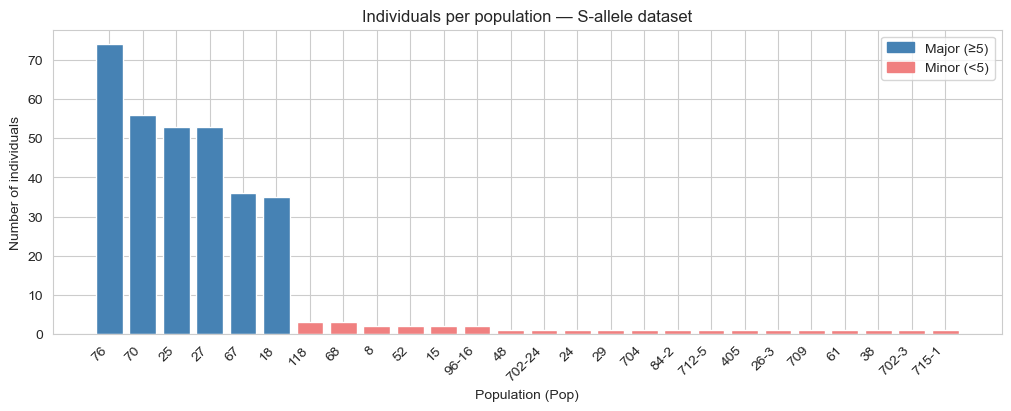

In [11]:
# --- Visualize population sizes ---
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
pops_sorted = pop_counts.index.tolist()
colors = ["steelblue" if c >= 5 else "lightcoral" for c in pop_counts.values]
ax.bar(range(len(pops_sorted)), pop_counts.values, color=colors, edgecolor="white")
ax.set_xticks(range(len(pops_sorted)))
ax.set_xticklabels(pops_sorted, rotation=45, ha="right")
ax.set_xlabel("Population (Pop)")
ax.set_ylabel("Number of individuals")
ax.set_title("Individuals per population — S-allele dataset")
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="Major (≥5)"),
    mpatches.Patch(color="lightcoral", label="Minor (<5)"),
])
plt.show()

## 9. EDA: Allele Prevalence

How many individuals carry each S-allele bin?
This informs allele rarity and crossing strategy.

In [12]:
# Allele prevalence (presence/absence) across ingroup individuals
ingroup_geno = genotypes_filtered.set_index("Individual")[allele_columns]
allele_prevalence = (ingroup_geno > 0).sum(axis=0).astype(int).sort_values(ascending=False)

detected_alleles = allele_prevalence[allele_prevalence > 0]
n_singletons = int((detected_alleles == 1).sum())

print(f"Total allele columns in matrix: {len(allele_columns)}")
print(f"Allele bins detected in ingroup: {len(detected_alleles)}")
print(f"Singletons (1 individual): {n_singletons}")
print(f"Core alleles (2+ individuals): {len(detected_alleles) - n_singletons}")
print(f"\nTop 10 most prevalent alleles:")
print(detected_alleles.head(10).to_string())

Total allele columns in matrix: 49
Allele bins detected in ingroup: 49
Singletons (1 individual): 15
Core alleles (2+ individuals): 34

Top 10 most prevalent alleles:
Allele_050    99
Allele_051    80
Allele_049    44
Allele_044    30
Allele_020    28
Allele_045    20
Allele_023    16
Allele_024    13
Allele_022    13
Allele_042     9


## 10. Allele Frequencies

Compute allele frequencies from assigned tetraploid genotypes (4 copies per individual).
Compare to the NFDS equilibrium target (equal frequency for all alleles).

Total allele bins (integer IDs): 49
Detected allele bins (freq > 0): 49
NFDS equilibrium frequency:      0.0204 (1/49)


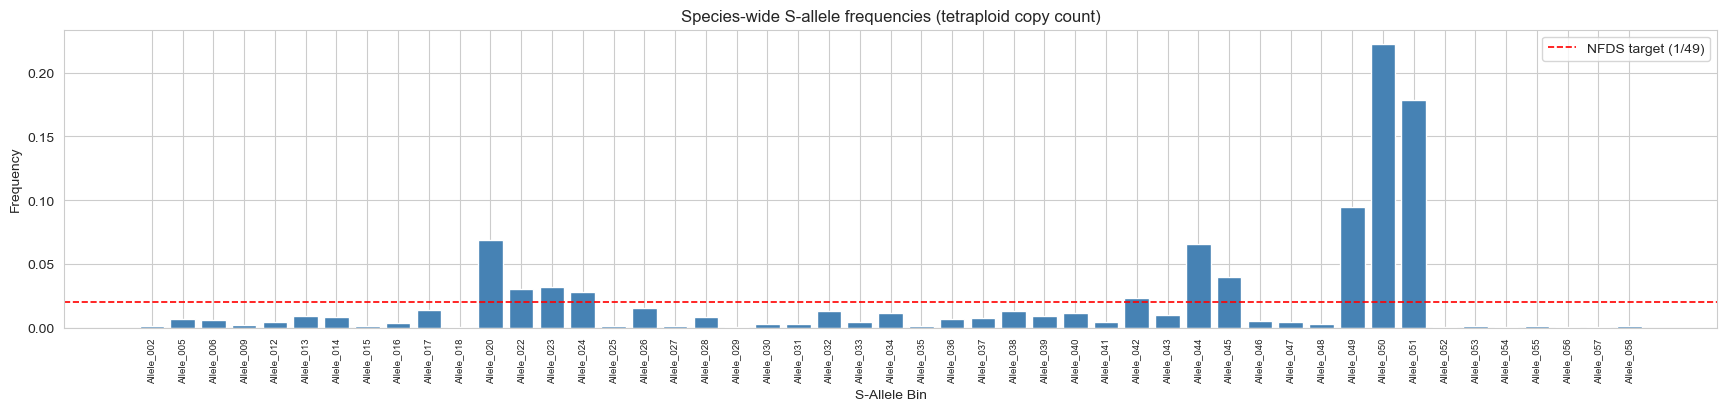

In [13]:
def allele_frequencies(population, allele_pool=None):
    """Compute allele frequencies from a list of genotype tuples."""
    counts = Counter()
    total = 0
    for genotype in population:
        for allele in genotype:
            counts[allele] += 1
            total += 1
    freqs = {a: counts[a] / total for a in counts}
    if allele_pool is not None:
        for a in allele_pool:
            if a not in freqs:
                freqs[a] = 0.0
    return dict(sorted(freqs.items()))


# Species-wide allele frequencies
species_freqs = allele_frequencies(population_genotypes, allele_pool)
detected_freq_ids = [a for a, f in species_freqs.items() if f > 0]
n_detected = len(detected_freq_ids)
nfds_target = 1.0 / n_detected if n_detected > 0 else 0

print(f"Total allele bins (integer IDs): {len(allele_pool)}")
print(f"Detected allele bins (freq > 0): {n_detected}")
print(f"NFDS equilibrium frequency:      {nfds_target:.4f} (1/{n_detected})")

# Plot species-wide allele frequencies
freq_vals = [species_freqs[a] for a in detected_freq_ids]
allele_names_detected = [id_to_name[a] for a in detected_freq_ids]

fig, ax = plt.subplots(figsize=(max(12, n_detected * 0.35), 4), layout="constrained")
ax.bar(range(n_detected), freq_vals, color="steelblue", edgecolor="white")
ax.axhline(nfds_target, color="red", linestyle="--", linewidth=1.2, label=f"NFDS target (1/{n_detected})")
ax.set_xticks(range(n_detected))
ax.set_xticklabels(allele_names_detected, rotation=90, fontsize=7)
ax.set_xlabel("S-Allele Bin")
ax.set_ylabel("Frequency")
ax.set_title("Species-wide S-allele frequencies (tetraploid copy count)")
ax.legend()
plt.show()

## 11. Per-Population Allele Frequencies

Compare allele frequency distributions across populations to reveal shared vs. private alleles
and identify cross-population crossing opportunities.

In [14]:
# Core alleles: present in 2+ ingroup individuals
core_allele_names = detected_alleles[detected_alleles >= 2].index.tolist()
core_allele_ids   = sorted([name_to_id[a] for a in core_allele_names])
print(f"Core alleles (in 2+ individuals): {len(core_allele_ids)}")
print(f"Singleton alleles (excluded from heatmap): {n_singletons}")

# Build frequency matrix: populations × core alleles (populations with >= 2 individuals)
display_pops = [p for p in pop_counts.index if pop_counts[p] >= 2]
freq_matrix = pd.DataFrame(index=display_pops, columns=core_allele_ids, dtype=float)
for pop in display_pops:
    pf = allele_frequencies(pop_populations[pop], allele_pool)
    for a in core_allele_ids:
        freq_matrix.loc[pop, a] = pf.get(a, 0.0)

print(f"\nFrequency matrix shape: {freq_matrix.shape}")

Core alleles (in 2+ individuals): 34
Singleton alleles (excluded from heatmap): 15

Frequency matrix shape: (12, 34)


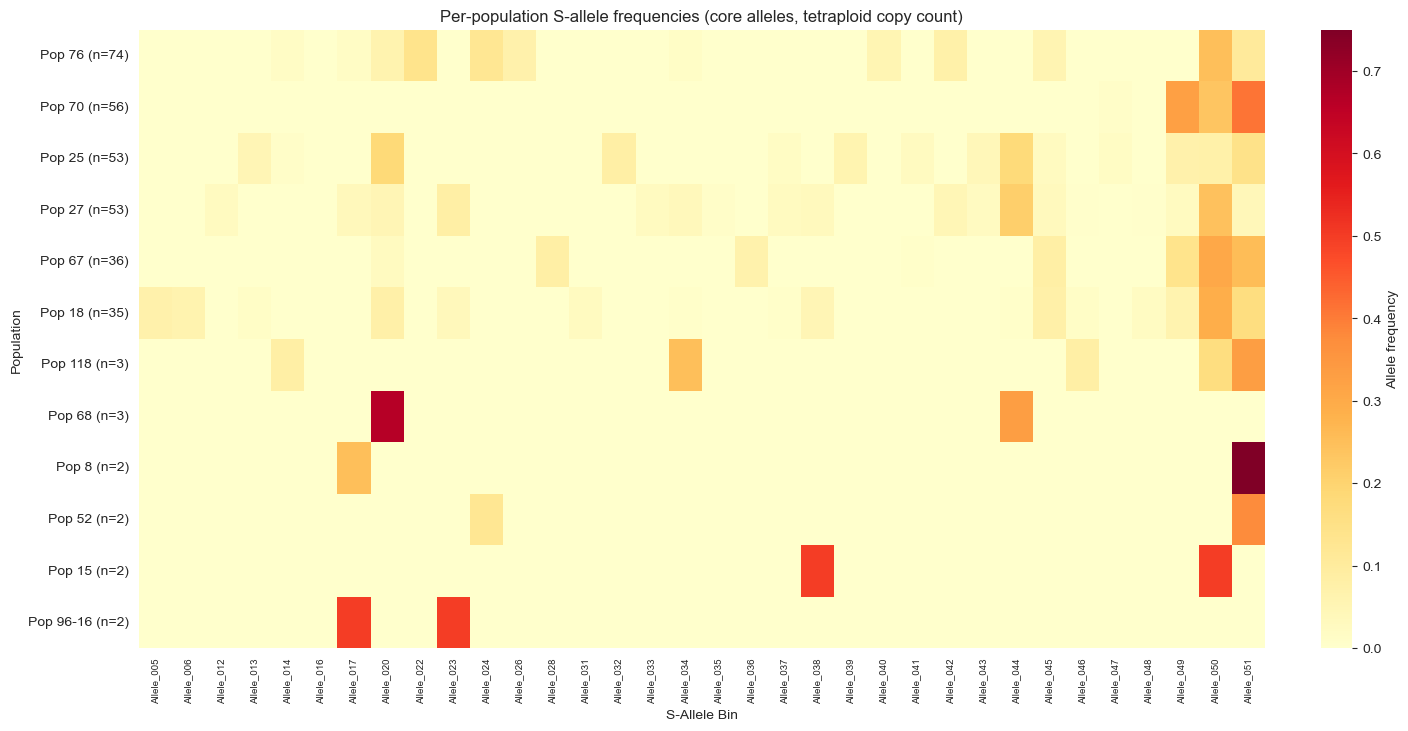

In [15]:
# Heatmap of per-population allele frequencies
fig, ax = plt.subplots(
    figsize=(max(14, len(core_allele_ids) * 0.35), max(4, len(display_pops) * 0.6)),
    layout="constrained"
)
sns.heatmap(
    freq_matrix.astype(float),
    xticklabels=[id_to_name[a] for a in core_allele_ids],
    yticklabels=[f"Pop {p} (n={len(pop_populations[p])})" for p in display_pops],
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Allele frequency"},
)
ax.set_xlabel("S-Allele Bin")
ax.set_ylabel("Population")
ax.set_title("Per-population S-allele frequencies (core alleles, tetraploid copy count)")
ax.tick_params(axis="x", labelsize=7)
plt.show()

## 12. Data Quality Summary

In [16]:
genotype_counts = zygosity_filtered["Genotype"].value_counts()

summary_data = {
    "Metric": [
        "Total individuals in input data",
        "Ingroup individuals with genotypes",
        "Excluded (outgroup + no metadata)",
        "Distinct S-allele bins in matrix",
        "Allele bins detected in ingroup",
        "Singleton alleles (1 individual)",
        "Core alleles (2+ individuals)",
        "Unique populations (Pop)",
        "Major populations (>= 5 individuals)",
        "AAAA (homozygous) genotypes",
        "AABB (2-allele, equal dosage) genotypes",
        "AAAB (2-allele, 3:1 dosage) genotypes",
        "AABC (3-allele, doubled) genotypes",
        "ABCD (4-allele) genotypes",
        "Genotypes requiring count-based resolution (AAAB + AABC)",
        "Genotypes fully deterministic (AAAA + AABB + ABCD)",
    ],
    "Value": [
        len(zygosity_df),
        len(assignments_df),
        len(zygosity_df) - len(assignments_df),
        len(allele_columns),
        len(detected_alleles),
        int(n_singletons),
        len(detected_alleles) - int(n_singletons),
        len(pop_populations),
        int((pop_counts >= 5).sum()),
        int(genotype_counts.get("AAAA", 0)),
        int(genotype_counts.get("AABB", 0)),
        int(genotype_counts.get("AAAB", 0)),
        int(genotype_counts.get("AABC", 0)),
        int(genotype_counts.get("ABCD", 0)),
        int(genotype_counts.get("AAAB", 0)) + int(genotype_counts.get("AABC", 0)),
        int(genotype_counts.get("AAAA", 0)) + int(genotype_counts.get("AABB", 0)) + int(genotype_counts.get("ABCD", 0)),
    ],
}

summary_table = pd.DataFrame(summary_data)
print("Data Quality Summary")
print("=" * 60)
print(summary_table.to_string(index=False))

Data Quality Summary
                                                  Metric  Value
                         Total individuals in input data    335
                      Ingroup individuals with genotypes    335
                       Excluded (outgroup + no metadata)      0
                        Distinct S-allele bins in matrix     49
                         Allele bins detected in ingroup     49
                        Singleton alleles (1 individual)     15
                           Core alleles (2+ individuals)     34
                                Unique populations (Pop)     26
                    Major populations (>= 5 individuals)      6
                             AAAA (homozygous) genotypes    211
                 AABB (2-allele, equal dosage) genotypes     57
                   AAAB (2-allele, 3:1 dosage) genotypes     52
                      AABC (3-allele, doubled) genotypes     15
                               ABCD (4-allele) genotypes      0
Genotypes requiring

## 13. Load Synonymy Groups

The wide allele matrix above is at the **protein level** (49 protein-defined allele bins). Upstream sequence analysis (`srk_allele_hypotheses.py` Step 22b) groups proteins with identical hypervariable (HV) residues into **synonymy groups** — clusters that share SI-recognition specificity. For the polyploid crossing model these must be collapsed into **biological alleles**: an AABB plant where both B alleles are in the same synonymy group is really AAAB at the level of SI specificity.

`SRK_synonymy_groups.csv` schema:

| Column | Description |
|---|---|
| `Allele` | Protein-level allele label (e.g. `Allele_022`) |
| `Synonymy_group` | `Isolated` or `Synonymy group N` (N = 1..8) |
| `Group_size` | Number of protein alleles in the group |
| `Obs_count` | Observation count for this protein allele in the ingroup |
| `AAAA_count` | Times observed in an AAAA individual |
| `Group_obs_total` | Total observations summed across the whole group |

In [17]:
synonymy_path = os.path.join(SALLELES_DIR, "SRK_synonymy_groups.csv")
synonymy_df = pd.read_csv(synonymy_path, encoding="utf-8-sig")

# Drop entirely empty trailing rows that some CSV writers append
synonymy_df = synonymy_df.dropna(subset=["Allele"]).reset_index(drop=True)

print(f"Synonymy file: {len(synonymy_df)} protein alleles")
print(f"\nSynonymy group categories:")
print(synonymy_df["Synonymy_group"].value_counts().to_string())
print(f"\nSample rows:")
print(synonymy_df.head(10).to_string(index=False))

Synonymy file: 58 protein alleles

Synonymy group categories:
Synonymy_group
Isolated            19
Synonymy group 1    15
Synonymy group 2     9
Synonymy group 3     4
Synonymy group 4     3
Synonymy group 5     2
Synonymy group 6     2
Synonymy group 7     2
Synonymy group 8     2

Sample rows:
    Allele Synonymy_group  Group_size  Obs_count  AAAA_count  Group_obs_total
Allele_001       Isolated           1          0           0                0
Allele_002       Isolated           1          1           0                1
Allele_003       Isolated           1          0           0                0
Allele_004       Isolated           1          0           0                0
Allele_005       Isolated           1          3           2                3
Allele_008       Isolated           1          0           0                0
Allele_009       Isolated           1          1           0                1
Allele_010       Isolated           1          0           0                0


## 14. Build Biological-Allele Mapping

Each **biological allele** represents one SI-recognition specificity. Mapping rules:

- An **Isolated** protein allele keeps its original label (e.g. `Allele_022`).
- Each **Synonymy group** collapses into one biological allele labelled `Synonymy_group_N` for group N ∈ {1, 2, ..., 8}.

For the LEPA 2026-05-11 dataset the synonymy pool contains 58 protein-level alleles → **27 biological alleles** (19 isolated + 8 groups). Group 1 (15 members, including the pan-BL `Allele_050` and `Allele_051`) is the dominant AAAA-fixation driver per the LEPA report Q6.

In [18]:
import re as _re

def _biological_label(row):
    """Map a protein-level allele to its biological-allele label.
    Isolated -> protein name kept (e.g. 'Allele_022'); grouped -> 'Synonymy_group_N'.
    """
    grp = str(row["Synonymy_group"]).strip()
    if grp == "Isolated":
        return row["Allele"]
    m = _re.match(r"Synonymy group (\d+)$", grp)
    if m:
        return f"Synonymy_group_{int(m.group(1))}"
    raise ValueError(f"Unexpected synonymy group label: {grp!r}")


# Build protein -> biological mapping
synonymy_df["biological_allele"] = synonymy_df.apply(_biological_label, axis=1)
protein_to_bio = dict(zip(synonymy_df["Allele"], synonymy_df["biological_allele"]))

# Cover any protein-level columns in the matrix not represented in the synonymy file
# (defensive — should not happen if the upstream files are consistent)
for prot in allele_columns:
    if prot not in protein_to_bio:
        protein_to_bio[prot] = prot  # treat as isolated

# All biological alleles in the synonymy pool
all_bio_alleles = sorted(set(synonymy_df["biological_allele"]))

# Members per biological allele (for reporting)
bio_to_proteins = {}
for prot, bio in protein_to_bio.items():
    bio_to_proteins.setdefault(bio, []).append(prot)
for bio in bio_to_proteins:
    bio_to_proteins[bio].sort()

# Biological alleles observed in the protein matrix (only those with detected protein columns)
observed_bio_alleles = sorted(set(
    protein_to_bio[a] for a in allele_columns if a in protein_to_bio
))

print(f"Total biological alleles in synonymy pool: {len(all_bio_alleles)}")
print(f"Observed biological alleles (matrix columns map to): {len(observed_bio_alleles)}")
print(f"\nSynonymy groups (>1 member) — protein members:")
for bio in sorted(all_bio_alleles):
    members = bio_to_proteins.get(bio, [])
    if len(members) > 1:
        sample = ", ".join(members[:6])
        suffix = "..." if len(members) > 6 else ""
        print(f"  {bio}: {len(members)} alleles ({sample}{suffix})")

Total biological alleles in synonymy pool: 27
Observed biological alleles (matrix columns map to): 21

Synonymy groups (>1 member) — protein members:
  Synonymy_group_1: 15 alleles (Allele_019, Allele_021, Allele_032, Allele_039, Allele_040, Allele_042...)
  Synonymy_group_2: 9 alleles (Allele_020, Allele_023, Allele_024, Allele_027, Allele_034, Allele_035...)
  Synonymy_group_3: 4 alleles (Allele_030, Allele_044, Allele_056, Allele_057)
  Synonymy_group_4: 3 alleles (Allele_014, Allele_015, Allele_025)
  Synonymy_group_5: 2 alleles (Allele_006, Allele_007)
  Synonymy_group_6: 2 alleles (Allele_013, Allele_026)
  Synonymy_group_7: 2 alleles (Allele_017, Allele_018)
  Synonymy_group_8: 2 alleles (Allele_028, Allele_029)


## 15. Collapse to Biological Copy Counts

For each individual, sum the protein-level copy counts within each biological allele. The resulting biological-level dosages are then used for the model.

Note that, like the protein-level wide matrix, these biological counts are **protein counts summed within groups, not true tetraploid copy counts**. The 4-copy-per-individual constraint is reasserted via the assignment step (section 4) which derives copy counts from `Genotype` + `Allele_composition`. The biological dosages here are most useful as an inspection / sanity-check matrix.

In [19]:
# Map protein columns to biological labels
allele_to_bio = {a: protein_to_bio.get(a, a) for a in allele_columns}


def collapse_protein_counts_to_biological(protein_count_row):
    """Sum protein-level copy counts within each biological allele.

    Parameters
    ----------
    protein_count_row : pd.Series
        Row from the wide protein matrix (one individual).

    Returns
    -------
    dict[str, int]
        biological_allele -> protein-count sum (non-zero entries only).
    """
    bio_counts = {}
    for prot in allele_columns:
        c = int(protein_count_row[prot])
        if c == 0:
            continue
        bio = allele_to_bio[prot]
        bio_counts[bio] = bio_counts.get(bio, 0) + c
    return bio_counts


# Apply collapse to every ingroup individual
bio_counts_per_individual = {
    ind: collapse_protein_counts_to_biological(geno_indexed.loc[ind])
    for ind in zygosity_filtered["Individual"]
}

# Wide biological-level matrix for inspection (alphabetical column order;
# canonical alphanumeric ordering is established when integer IDs are assigned in section 17)
bio_matrix = (
    pd.DataFrame.from_dict(bio_counts_per_individual, orient="index")
      .fillna(0)
      .astype(int)
)
bio_matrix = bio_matrix.reindex(columns=sorted(bio_matrix.columns))
bio_matrix.index.name = "Individual"

print(f"Biological count matrix: {bio_matrix.shape[0]} individuals x {bio_matrix.shape[1]} biological alleles")
print(f"\nExample: protein-level -> biological-level for AABC individuals")
aabc_examples = assignments_df[assignments_df["genotype_pattern"] == "AABC"].head(3)
for _, row in aabc_examples.iterrows():
    ind = row["individual"]
    prot_counts = row["allele_counts"]
    bio_counts = bio_counts_per_individual[ind]
    print(f"  {ind}")
    print(f"    Protein-level counts:    {prot_counts}")
    print(f"    Biological-level counts: {bio_counts}")

Biological count matrix: 335 individuals x 21 biological alleles

Example: protein-level -> biological-level for AABC individuals
  Library001_barcode02
    Protein-level counts:    {'Allele_018': 1, 'Allele_049': 2, 'Allele_050': 1}
    Biological-level counts: {'Synonymy_group_7': 1, 'Synonymy_group_1': 3}
  Library002_barcode43
    Protein-level counts:    {'Allele_014': 1, 'Allele_046': 1, 'Allele_050': 2}
    Biological-level counts: {'Synonymy_group_4': 1, 'Synonymy_group_1': 3}
  Library002_barcode51
    Protein-level counts:    {'Allele_013': 2, 'Allele_044': 1, 'Allele_046': 1}
    Biological-level counts: {'Synonymy_group_6': 2, 'Synonymy_group_3': 1, 'Synonymy_group_1': 1}


## 16. Recompute Genotype Tier at the Biological Level

The `Genotype` column in `SRK_individual_zygosity.tsv` is computed at the **protein level** — an individual labelled `AABC` upstream may be `AAAB` or even `AAAA` at the biological level if two or more of its protein-level alleles fall in the same synonymy group.

The tier at biological level is determined by the **copy counts of distinct biological alleles** in the assigned 4-tuple:

| Sorted copy counts | Tier |
|---|---|
| (4,) | AAAA |
| (3, 1) | AAAB |
| (2, 2) | AABB |
| (2, 1, 1) | AABC |
| (1, 1, 1, 1) | ABCD |

The polyploid crossing model operates on the biological tier (and GFS / TP1 / TP2 metrics are computed on biological alleles). Do **not** rely on the upstream `Genotype` column downstream.

In [20]:
# Stable canonical ordering: isolated alleles first (alphanumeric), then synonymy groups
def _bio_sort_key(label):
    if label.startswith("Allele_"):
        return (0, label)
    return (1, label)

bio_pool_full = sorted(set(synonymy_df["biological_allele"]), key=_bio_sort_key)
bio_name_to_id = {name: i + 1 for i, name in enumerate(bio_pool_full)}
bio_id_to_name = {v: k for k, v in bio_name_to_id.items()}
bio_allele_pool = sorted(bio_name_to_id.values())


def tier_from_copy_counts(counts):
    """Given a list/tuple of copy counts, return the tetraploid genotype tier label."""
    sorted_counts = tuple(sorted(counts, reverse=True))
    return {
        (4,):           "AAAA",
        (3, 1):         "AAAB",
        (2, 2):         "AABB",
        (2, 1, 1):      "AABC",
        (1, 1, 1, 1):   "ABCD",
    }[sorted_counts]


def biological_genotype_from_protein(protein_genotype, protein_to_bio):
    """Convert a 4-tuple of protein alleles to a 4-tuple of biological alleles (sorted)."""
    return tuple(sorted(protein_to_bio.get(a, a) for a in protein_genotype))


# Apply biological collapse to each individual's assigned (protein-level) genotype
biological_records = []
tier_changes = []
for _, row in assignments_df.iterrows():
    ind = row["individual"]
    protein_geno = row["genotype"]
    protein_tier = row["genotype_pattern"]

    bio_geno = biological_genotype_from_protein(protein_geno, protein_to_bio)
    bio_counter = Counter(bio_geno)
    bio_counts_list = sorted(bio_counter.values(), reverse=True)
    bio_tier = tier_from_copy_counts(bio_counts_list)

    biological_records.append({
        "individual":          ind,
        "protein_genotype":    protein_geno,
        "protein_tier":        protein_tier,
        "biological_genotype": bio_geno,
        "biological_tier":     bio_tier,
        "biological_dosage":   dict(bio_counter),
    })

    if protein_tier != bio_tier:
        tier_changes.append((ind, protein_tier, bio_tier, protein_geno, bio_geno))

biological_df = pd.DataFrame(biological_records)

print("Biological tier distribution (after synonymy collapse):")
print(biological_df["biological_tier"].value_counts().to_string())
print(f"\nProtein-level tier distribution (for comparison):")
print(zygosity_filtered["Genotype"].value_counts().to_string())
print(f"\nIndividuals reclassified by biological collapse: {len(tier_changes)}")
if tier_changes:
    print(f"\nFirst 10 reclassifications:")
    for ind, p_tier, b_tier, p_geno, b_geno in tier_changes[:10]:
        print(f"  {ind}: {p_tier} -> {b_tier}")
        print(f"    protein:    {p_geno}")
        print(f"    biological: {b_geno}")

Biological tier distribution (after synonymy collapse):
biological_tier
AAAA    261
AABB     41
AAAB     31
AABC      2

Protein-level tier distribution (for comparison):
Genotype
AAAA    211
AABB     57
AAAB     52
AABC     15

Individuals reclassified by biological collapse: 58

First 10 reclassifications:
  Library001_barcode02: AABC -> AAAB
    protein:    ('Allele_018', 'Allele_049', 'Allele_049', 'Allele_050')
    biological: ('Synonymy_group_1', 'Synonymy_group_1', 'Synonymy_group_1', 'Synonymy_group_7')
  Library001_barcode18: AAAB -> AAAA
    protein:    ('Allele_045', 'Allele_050', 'Allele_050', 'Allele_050')
    biological: ('Synonymy_group_1', 'Synonymy_group_1', 'Synonymy_group_1', 'Synonymy_group_1')
  Library002_barcode39: AAAB -> AAAA
    protein:    ('Allele_047', 'Allele_051', 'Allele_051', 'Allele_051')
    biological: ('Synonymy_group_1', 'Synonymy_group_1', 'Synonymy_group_1', 'Synonymy_group_1')
  Library002_barcode42: AABB -> AAAA
    protein:    ('Allele_050', '

## 17. Build Biological Population for the Model

Assign stable integer IDs to biological alleles and produce the biological-level population (4-tuples of integer biological-allele IDs).

The integer mapping is built from the **full biological allele pool** (all 27 alleles in the synonymy file, including unobserved ones) sorted alphanumerically — isolated alleles (`Allele_NNN`) come before synonymy groups (`Synonymy_group_N`). This keeps IDs stable across runs even if more individuals (with new observed alleles) are added later.

In [21]:
# Build biological-level population (integer tuples) parallel to population_genotypes
bio_population_genotypes = []
for _, row in biological_df.iterrows():
    int_genotype = tuple(sorted(bio_name_to_id[a] for a in row["biological_genotype"]))
    bio_population_genotypes.append(int_genotype)

# Per-population grouping at biological level
bio_pop_populations = {}
for ind, bio_geno in zip(biological_df["individual"], bio_population_genotypes):
    p = pop_map.get(ind, "unknown")
    bio_pop_populations.setdefault(p, []).append(bio_geno)

print(f"Biological allele pool: {len(bio_allele_pool)} alleles (IDs 1..{len(bio_allele_pool)})")
print(f"Observed in dataset: {len(observed_bio_alleles)}")
print(f"\nFirst 5 mappings (biological allele -> int ID):")
for name in bio_pool_full[:5]:
    print(f"  {name} -> {bio_name_to_id[name]}")
print(f"\nLast 5 mappings:")
for name in bio_pool_full[-5:]:
    print(f"  {name} -> {bio_name_to_id[name]}")

print(f"\nFirst 5 biological genotypes (integer IDs):")
for i in range(min(5, len(bio_population_genotypes))):
    ind = biological_df.iloc[i]["individual"]
    bio_tuple = biological_df.iloc[i]["biological_genotype"]
    print(f"  {ind}")
    print(f"    biological tuple: {bio_tuple}")
    print(f"    integer IDs:      {bio_population_genotypes[i]}")

Biological allele pool: 27 alleles (IDs 1..27)
Observed in dataset: 21

First 5 mappings (biological allele -> int ID):
  Allele_001 -> 1
  Allele_002 -> 2
  Allele_003 -> 3
  Allele_004 -> 4
  Allele_005 -> 5

Last 5 mappings:
  Synonymy_group_4 -> 23
  Synonymy_group_5 -> 24
  Synonymy_group_6 -> 25
  Synonymy_group_7 -> 26
  Synonymy_group_8 -> 27

First 5 biological genotypes (integer IDs):
  Library001_barcode02
    biological tuple: ('Synonymy_group_1', 'Synonymy_group_1', 'Synonymy_group_1', 'Synonymy_group_7')
    integer IDs:      (20, 20, 20, 26)
  Library001_barcode03
    biological tuple: ('Synonymy_group_7', 'Synonymy_group_7', 'Synonymy_group_7', 'Synonymy_group_7')
    integer IDs:      (26, 26, 26, 26)
  Library001_barcode04
    biological tuple: ('Synonymy_group_2', 'Synonymy_group_2', 'Synonymy_group_2', 'Synonymy_group_2')
    integer IDs:      (21, 21, 21, 21)
  Library001_barcode05
    biological tuple: ('Allele_016', 'Allele_016', 'Allele_016', 'Allele_016')
    i

## 18. Load BL Data and Annotate Individuals

Join each individual to its Element Occurrence (EO), Bottleneck Lineage (BL), and Drift index using the upstream spatial framework. Mapping chain:

```
sampling_metadata.csv (Pop column)
    └─ normalise_pop_to_eo()  →  EO label (e.g. "EO27")
                                     └─ EO_group_BL_summary.csv  →  BL, Drift_index
```

`src/bl_constants.py` mirrors `srk_bl_constants.py` from upstream and exposes the locked Set1 BL palette, `BL_ORDER` (area-then-connectivity), `BL_ORDER_NUMERIC` (alphanumeric for scatter legends), and the join helpers. Germplasm sub-codes that don't map to a numeric EO (e.g. "96-16", "702-3") are tagged `BL_status="Unassigned"` and excluded from BL-stratified analyses but kept in the protein/biological views.

The LEPA report's central conservation finding is that inter-BL transfers are the only recovery mechanism — carrying BL annotations through the model lets us simulate, recommend, and evaluate within-BL vs across-BL crosses.

In [22]:
import sys
sys.path.insert(0, "../src")
from bl_constants import (
    BL_COLORS,
    BL_ORDER,
    BL_ORDER_NUMERIC,
    load_eo_to_bl,
    normalise_pop_to_eo,
    get_eo_order_within_bl,
)

# Load EO -> BL/Drift_index lookup from upstream tables (mirrored into data/salleles/)
eo_to_bl = load_eo_to_bl(os.path.join(SALLELES_DIR, "EO_group_BL_summary.csv"))
known_eos = set(eo_to_bl)

# Join each individual to EO/BL via Pop -> EO
individual_to_eo = {}
individual_to_bl = {}
individual_to_drift_index = {}
individual_to_bl_status = {}
for ind in individual_names:
    pop = pop_map.get(ind, "")
    eo, status = normalise_pop_to_eo(pop, known_eos)
    individual_to_eo[ind] = eo
    individual_to_bl_status[ind] = status
    if eo and eo in eo_to_bl:
        individual_to_bl[ind] = eo_to_bl[eo]["BL"]
        individual_to_drift_index[ind] = eo_to_bl[eo]["Drift_index"]
    else:
        individual_to_bl[ind] = None
        individual_to_drift_index[ind] = None

# Diagnostic counts
status_counts = Counter(individual_to_bl_status.values())
bl_counts = Counter(b for b in individual_to_bl.values() if b)

print(f"BL ordering (area then connectivity): {BL_ORDER}")
print(f"BL ordering (alphanumeric, for scatter legends): {BL_ORDER_NUMERIC}")
print(f"\nIndividual assignment status:")
for st, n in status_counts.most_common():
    print(f"  {st}: {n}")
print(f"\nIndividuals per BL (in BL_ORDER):")
for bl in BL_ORDER:
    print(f"  {bl} {BL_COLORS[bl]}: {bl_counts.get(bl, 0)} individuals")
unassigned = [ind for ind, st in individual_to_bl_status.items() if st == "Unassigned"]
if unassigned:
    print(f"\nUnassigned individuals (no EO match, typically germplasm sub-codes):")
    for ind in unassigned[:10]:
        print(f"  {ind} (Pop={pop_map.get(ind, '?')})")
    if len(unassigned) > 10:
        print(f"  ... and {len(unassigned) - 10} more")

BL ordering (area then connectivity): ['BL4', 'BL5', 'BL3', 'BL1', 'BL2']
BL ordering (alphanumeric, for scatter legends): ['BL1', 'BL2', 'BL3', 'BL4', 'BL5']

Individual assignment status:
  Assigned: 322
  Unassigned: 10
  Inferred: 3

Individuals per BL (in BL_ORDER):
  BL4 #FF7F00: 89 individuals
  BL5 #4DAF4A: 92 individuals
  BL3 #E41A1C: 80 individuals
  BL1 #984EA3: 5 individuals
  BL2 #377EB8: 59 individuals

Unassigned individuals (no EO match, typically germplasm sub-codes):
  Library001_barcode03 (Pop=96-16)
  Library001_barcode04 (Pop=702-3)
  Library001_barcode05 (Pop=712-5)
  Library001_barcode11 (Pop=709)
  Library002_barcode23 (Pop=96-16)
  Library002_barcode29 (Pop=405)
  Library002_barcode34 (Pop=84-2)
  Library002_barcode36 (Pop=704)
  Library002_barcode52 (Pop=702-24)
  Library002_barcode53 (Pop=715-1)


## 19. Group by EO and BL

Build biological-allele population groupings keyed by EO and BL for stratified downstream analyses (TP1 panels, BL-aggregate convergence plots, per-population GFS dashboards). The existing Pop-keyed grouping in section 8 stays available for reference, but EO/BL are the canonical conservation units.

In [23]:
# Group biological genotypes by EO
eo_populations = {}
eo_individuals = {}
for ind, bio_geno in zip(individual_names, bio_population_genotypes):
    eo = individual_to_eo.get(ind)
    if eo is None:
        continue
    eo_populations.setdefault(eo, []).append(bio_geno)
    eo_individuals.setdefault(eo, []).append(ind)

# Group biological genotypes by BL
bl_populations = {}
bl_individuals = {}
for ind, bio_geno in zip(individual_names, bio_population_genotypes):
    bl = individual_to_bl.get(ind)
    if bl is None:
        continue
    bl_populations.setdefault(bl, []).append(bio_geno)
    bl_individuals.setdefault(bl, []).append(ind)

# Order EOs within BL by ascending Drift_index (matches upstream srk_bl_constants helper)
observed_eos = sorted(eo_populations.keys())
ordered_eos = get_eo_order_within_bl(
    observed_eos,
    os.path.join(SALLELES_DIR, "EO_group_BL_summary.csv"),
)

print(f"EOs with sampled individuals: {len(eo_populations)}")
print(f"\nEOs ordered (within BL by ascending Drift_index):")
for eo in ordered_eos:
    bl = eo_to_bl.get(eo, {}).get("BL", "?")
    di = eo_to_bl.get(eo, {}).get("Drift_index", "?")
    n = len(eo_populations.get(eo, []))
    print(f"  {eo} ({bl}, Drift_index={di}): {n} individuals")

print(f"\nBL aggregate populations (BL_ORDER):")
for bl in BL_ORDER:
    n = len(bl_populations.get(bl, []))
    print(f"  {bl}: {n} individuals")

EOs with sampled individuals: 16

EOs ordered (within BL by ascending Drift_index):
  EO27 (BL4, Drift_index=0.6747): 53 individuals
  EO67 (BL4, Drift_index=1.0): 36 individuals
  EO18 (BL5, Drift_index=0.588): 37 individuals
  EO25 (BL5, Drift_index=0.978): 53 individuals
  EO24 (BL5, Drift_index=1.0): 1 individuals
  EO48 (BL5, Drift_index=1.0): 1 individuals
  EO118 (BL3, Drift_index=0.411): 3 individuals
  EO76 (BL3, Drift_index=0.411): 74 individuals
  EO38 (BL3, Drift_index=0.938): 1 individuals
  EO52 (BL3, Drift_index=0.987): 2 individuals
  EO08 (BL1, Drift_index=0.9097): 2 individuals
  EO61 (BL1, Drift_index=0.955): 1 individuals
  EO26 (BL1, Drift_index=0.982): 1 individuals
  EO29 (BL1, Drift_index=0.998): 1 individuals
  EO70 (BL2, Drift_index=0.999): 56 individuals
  EO68 (BL2, Drift_index=1.0): 3 individuals

BL aggregate populations (BL_ORDER):
  BL4: 89 individuals
  BL5: 92 individuals
  BL3: 80 individuals
  BL1: 5 individuals
  BL2: 59 individuals


## 20. Export Data

Save the assigned population data for downstream notebooks. Both the protein-level and biological-level views are exported plus EO/BL annotations -- biological is the canonical view used by the crossing model.

| File | Format | Contents |
|---|---|---|
| `data/population.pkl` | Pickle | Full population data dict (protein + biological genotypes, EO/BL annotations, synonymy mapping, pop groups, BL aggregates) |
| `data/assigned_genotypes.tsv` | TSV | Human-readable genotype assignments with Pop, EO, BL, Drift_index, protein tier, biological tier |

In [24]:
# --- Build export data (protein + biological views, plus EO/BL annotations) ---
export_data = {
    # ===== Biological view (canonical for the crossing model) =====
    "population":               bio_population_genotypes,    # list[tuple[int]] - biological allele IDs
    "individual_names":         individual_names,             # parallel list of individual IDs
    "allele_pool":              bio_allele_pool,              # full biological allele integer pool
    "name_to_id":               bio_name_to_id,               # biological allele name -> int
    "id_to_name":               bio_id_to_name,               # int -> biological allele name
    "pop_map":                  pop_map,                      # individual -> raw Pop (legacy)
    "pop_populations":          bio_pop_populations,          # Pop -> list of biological genotypes (legacy)
    "pop_individuals":          pop_individuals,              # Pop -> list of individuals (legacy)
    "biological_tiers":         dict(zip(biological_df["individual"], biological_df["biological_tier"])),

    # ===== EO / BL annotations (canonical grouping for conservation analyses) =====
    "individual_to_eo":         individual_to_eo,             # individual -> "EO27" or None
    "individual_to_bl":         individual_to_bl,             # individual -> "BL4" or None
    "individual_to_drift_index": individual_to_drift_index,   # individual -> float or None
    "individual_to_bl_status":  individual_to_bl_status,      # individual -> Assigned/Inferred/Unassigned
    "eo_populations":           eo_populations,               # EO -> list of biological genotypes
    "eo_individuals":           eo_individuals,               # EO -> list of individuals
    "bl_populations":           bl_populations,               # BL -> list of biological genotypes
    "bl_individuals":           bl_individuals,               # BL -> list of individuals
    "eo_to_bl":                 eo_to_bl,                     # EO -> {BL, Group, Drift_index}
    "bl_order":                 BL_ORDER,                     # [BL4, BL5, BL3, BL1, BL2]
    "bl_order_numeric":         BL_ORDER_NUMERIC,             # [BL1..BL5]
    "bl_colors":                BL_COLORS,                    # locked Set1 palette
    "ordered_eos":              ordered_eos,                  # observed EOs in BL_ORDER + drift order

    # ===== Synonymy mapping =====
    "protein_to_bio":           protein_to_bio,               # protein allele name -> biological allele name
    "bio_to_proteins":          bio_to_proteins,              # biological allele name -> list of protein members
    "observed_bio_alleles":     observed_bio_alleles,
    "all_bio_alleles":          all_bio_alleles,

    # ===== Protein-level view (traceability / diagnostics) =====
    "protein_population":       population_genotypes,
    "protein_allele_pool":      allele_pool,
    "protein_name_to_id":       name_to_id,
    "protein_id_to_name":       id_to_name,
    "protein_pop_populations":  pop_populations,
    "protein_tiers":            dict(zip(biological_df["individual"], biological_df["protein_tier"])),
    "core_allele_ids":          core_allele_ids,              # legacy protein-level core alleles

    # ===== Full assignment records =====
    "assignments":              assignments_df.to_dict(orient="records"),
    "biological_assignments":   biological_df.to_dict(orient="records"),
}

# Save pickle
pkl_path = os.path.join(DATA_DIR, "population.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(export_data, f)
print(f"Saved pickle: {pkl_path}")

# --- Save human-readable TSV (with EO + BL columns) ---
tsv_rows = []
for i, row in biological_df.iterrows():
    ind = row["individual"]
    p_geno = row["protein_genotype"]
    b_geno = row["biological_genotype"]
    bio_ids = bio_population_genotypes[i]
    tsv_rows.append({
        "Individual":          ind,
        "Pop":                 pop_map.get(ind, "unknown"),
        "EO":                  individual_to_eo.get(ind) or "",
        "BL":                  individual_to_bl.get(ind) or "",
        "Drift_index":         individual_to_drift_index.get(ind) if individual_to_drift_index.get(ind) is not None else "",
        "BL_status":           individual_to_bl_status.get(ind, ""),
        "Protein_tier":        row["protein_tier"],
        "Biological_tier":     row["biological_tier"],
        "Protein_Allele_1":    p_geno[0],
        "Protein_Allele_2":    p_geno[1],
        "Protein_Allele_3":    p_geno[2],
        "Protein_Allele_4":    p_geno[3],
        "Biological_Allele_1": b_geno[0],
        "Biological_Allele_2": b_geno[1],
        "Biological_Allele_3": b_geno[2],
        "Biological_Allele_4": b_geno[3],
        "Bio_ID_1":            bio_ids[0],
        "Bio_ID_2":            bio_ids[1],
        "Bio_ID_3":            bio_ids[2],
        "Bio_ID_4":            bio_ids[3],
    })

tsv_df = pd.DataFrame(tsv_rows)
tsv_path = os.path.join(DATA_DIR, "assigned_genotypes.tsv")
tsv_df.to_csv(tsv_path, sep="\t", index=False)
print(f"Saved TSV: {tsv_path}")
print(f"\nFirst 10 rows (Individual / Pop / EO / BL / tiers):")
print(tsv_df[["Individual", "Pop", "EO", "BL", "Protein_tier", "Biological_tier"]].head(10).to_string(index=False))

Saved pickle: ../data/population.pkl
Saved TSV: ../data/assigned_genotypes.tsv

First 10 rows (Individual / Pop / EO / BL / tiers):
          Individual   Pop   EO  BL Protein_tier Biological_tier
Library001_barcode02    67 EO67 BL4         AABC            AAAB
Library001_barcode03 96-16                  AAAA            AAAA
Library001_barcode04 702-3                  AAAA            AAAA
Library001_barcode05 712-5                  AAAA            AAAA
Library001_barcode06    38 EO38 BL3         AAAA            AAAA
Library001_barcode07    61 EO61 BL1         AAAA            AAAA
Library001_barcode08    70 EO70 BL2         AAAA            AAAA
Library001_barcode09    76 EO76 BL3         AABB            AABB
Library001_barcode10    25 EO25 BL5         AAAA            AAAA
Library001_barcode11   709                  AABB            AABB


In [25]:
def load_population(data_dir=None):
    """Convenience function to load assigned population data.

    Returns a dict with biological (canonical) view, EO/BL annotations, and protein-level view:

    Biological view (use these in the crossing model):
        population             : list[tuple]    - biological genotypes (integer IDs)
        individual_names       : list[str]      - individuals (parallel to population)
        allele_pool            : list[int]      - all biological allele IDs (1..N)
        name_to_id             : dict[str,int]  - biological label -> int
        id_to_name             : dict[int,str]  - int -> biological label
        biological_tiers       : dict[str,str]  - individual -> tier (AAAA/.../ABCD)
        observed_bio_alleles   : list[str]      - biological alleles observed in dataset
        all_bio_alleles        : list[str]      - full biological allele pool (incl. unobserved)
        protein_to_bio         : dict[str,str]  - protein name -> biological name
        bio_to_proteins        : dict[str,list] - biological name -> list of protein members

    EO / BL annotations (use for stratified conservation analyses):
        individual_to_eo       : dict[str,str]  - individual -> EO label or None
        individual_to_bl       : dict[str,str]  - individual -> BL label or None
        individual_to_drift_index : dict[str,float] - individual -> Drift_index or None
        individual_to_bl_status: dict[str,str]  - Assigned / Inferred / Unassigned
        eo_populations         : dict[str,list] - EO -> list of biological genotypes
        eo_individuals         : dict[str,list] - EO -> list of individuals
        bl_populations         : dict[str,list] - BL -> list of biological genotypes
        bl_individuals         : dict[str,list] - BL -> list of individuals
        eo_to_bl               : dict[str,dict] - EO -> {BL, Group, Drift_index}
        bl_order               : list[str]      - BLs in area-then-connectivity order (for bars/panels)
        bl_order_numeric       : list[str]      - BLs alphanumeric (for scatter legends)
        bl_colors              : dict[str,str]  - BL -> hex colour (locked Set1)
        ordered_eos            : list[str]      - observed EOs sorted within-BL by drift

    Legacy Pop-keyed view (kept for backwards compatibility):
        pop_map                : dict[str,str]  - individual -> raw Pop
        pop_populations        : dict[str,list] - Pop -> list of biological genotypes
        pop_individuals        : dict[str,list] - Pop -> list of individuals

    Protein-level view (traceability):
        protein_population     : list[tuple]    - protein genotypes (integer IDs)
        protein_allele_pool    : list[int]
        protein_name_to_id, protein_id_to_name : dict
        protein_pop_populations: dict
        protein_tiers          : dict[str,str]
        core_allele_ids        : list[int]

    Full records:
        assignments            : list[dict]     - protein-level assignment details
        biological_assignments : list[dict]     - biological-level assignment details
    """
    if data_dir is None:
        data_dir = os.path.join("..", "data")
    pkl_path = os.path.join(data_dir, "population.pkl")
    with open(pkl_path, "rb") as f:
        return pickle.load(f)


# Verify round-trip
loaded = load_population(DATA_DIR)
assert loaded["population"]          == bio_population_genotypes
assert loaded["allele_pool"]         == bio_allele_pool
assert loaded["pop_map"]             == pop_map
assert loaded["protein_population"]  == population_genotypes
assert loaded["protein_allele_pool"] == allele_pool
assert loaded["individual_to_bl"]    == individual_to_bl
assert loaded["bl_order"]            == BL_ORDER
print("Round-trip verification PASSED.")
print(f"  Biological view:   {len(loaded['population'])} genotypes, {len(loaded['allele_pool'])} allele pool ({len(loaded['observed_bio_alleles'])} observed)")
print(f"  Protein view:      {len(loaded['protein_population'])} genotypes, {len(loaded['protein_allele_pool'])} allele pool")
print(f"  EO-stratified:     {len(loaded['eo_populations'])} EOs assigned")
print(f"  BL-stratified:     {sum(len(v) for v in loaded['bl_populations'].values())} individuals across {len(loaded['bl_populations'])} BLs")
print(f"  Pop-stratified:    {len(loaded['pop_populations'])} populations (legacy)")
print(f"\nTo load in other notebooks:")
print("  import pickle, sys")
print("  sys.path.insert(0, '../src')")
print("  from polyploid_utils import *")
print("  from bl_constants import BL_COLORS, BL_ORDER")
print("  data = pickle.load(open('../data/population.pkl', 'rb'))")
print("  population  = data['population']         # biological genotypes (canonical)")
print("  allele_pool = data['allele_pool']        # biological allele IDs")
print("  bl_pops     = data['bl_populations']     # BL-stratified populations")

Round-trip verification PASSED.
  Biological view:   335 genotypes, 27 allele pool (21 observed)
  Protein view:      335 genotypes, 49 allele pool
  EO-stratified:     16 EOs assigned
  BL-stratified:     325 individuals across 5 BLs
  Pop-stratified:    26 populations (legacy)

To load in other notebooks:
  import pickle, sys
  sys.path.insert(0, '../src')
  from polyploid_utils import *
  from bl_constants import BL_COLORS, BL_ORDER
  data = pickle.load(open('../data/population.pkl', 'rb'))
  population  = data['population']         # biological genotypes (canonical)
  allele_pool = data['allele_pool']        # biological allele IDs
  bl_pops     = data['bl_populations']     # BL-stratified populations
